# AG News Topic Classification with DistilBERT

Fine-tunes `distilbert-base-uncased` to classify AG News articles into 4 topics (World, Sports, Business, Sci/Tech).

- **Train:** 108,000 articles (90% of the official 120K training set)
- **Validation:** 12,000 articles (10% held out, used for model selection)
- **Test:** the official 7,600-article test set, used once at the end

**Run on Google Colab:** Runtime > Change runtime type > **T4 GPU**, then Runtime > Run all. Takes about 20-25 minutes.

In [1]:
!pip -q install -U transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.2 MB/s eta 0:00:00


In [2]:
import json, numpy as np, torch, matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding, set_seed)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

set_seed(42)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none - switch runtime to T4 GPU!")
LABELS = ["World", "Sports", "Business", "Sci/Tech"]

GPU: Tesla T4


## 1. Load data and create a validation split

In [3]:
ds = load_dataset("fancyzhx/ag_news")
split = ds["train"].train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
train_ds, val_ds, test_ds = split["train"], split["test"], ds["test"]
print(f"Train {len(train_ds):,} | Validation {len(val_ds):,} | Test {len(test_ds):,}")
print("Example:", train_ds[0]["text"][:200], "->", LABELS[train_ds[0]["label"]])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train 108,000 | Validation 12,000 | Test 7,600
Example: Three tied for lead at Southern Farm Bureau Classic John Senden carded a pair of eagles, Harrison Frazar shot a 31 on the front nine and Glen Day recorded seven birdies to finish Thursday #39;s first  -> Sports


## 2. Tokenize (max 128 tokens; most AG News articles are shorter)

In [4]:
MODEL = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL)
def encode(batch): return tok(batch["text"], truncation=True, max_length=128)
train_tok = train_ds.map(encode, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(encode, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(encode, batched=True, remove_columns=["text"])
lengths = [len(x) for x in val_tok["input_ids"]]
print(f"Token length: median {np.median(lengths):.0f}, 95th pct {np.percentile(lengths,95):.0f}, truncated {np.mean(np.array(lengths)>=128)*100:.1f}%")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Token length: median 50, 95th pct 81, truncated 0.7%


## 3. Fine-tune

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL, num_labels=4, id2label=dict(enumerate(LABELS)), label2id={l:i for i,l in enumerate(LABELS)})

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    prec, rec, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average="macro")
    return {"accuracy": accuracy_score(p.label_ids, preds), "macro_f1": f1, "macro_precision": prec, "macro_recall": rec}

args = TrainingArguments(
    output_dir="distilbert-agnews",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=128,
    num_train_epochs=2, weight_decay=0.01, warmup_steps=400,
    fp16=torch.cuda.is_available(), logging_steps=200,
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    save_total_limit=1, report_to="none", seed=42)

trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok,
                  data_collator=DataCollatorWithPadding(tok), compute_metrics=compute_metrics)
train_out = trainer.train()
print(f"Training time: {train_out.metrics['train_runtime']/60:.1f} min")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.192823,0.178128,0.939833,0.939818,0.940051,0.939833
2,0.137035,0.176805,0.944583,0.944577,0.944932,0.944583


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 10.2 min


## 4. Validation curve

Epoch 1: val loss 0.1781, val accuracy 93.98%
Epoch 2: val loss 0.1768, val accuracy 94.46%


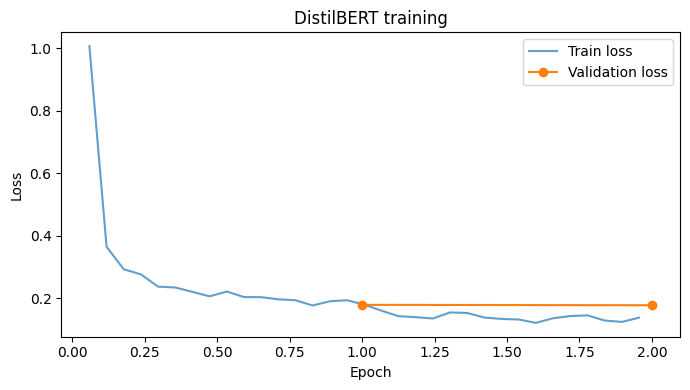

In [7]:
hist = trainer.state.log_history
tr = [(h["epoch"], h["loss"]) for h in hist if "loss" in h]
ev = [(h["epoch"], h["eval_loss"], h["eval_accuracy"]) for h in hist if "eval_loss" in h]
for e, l, a in ev: print(f"Epoch {e:.0f}: val loss {l:.4f}, val accuracy {a*100:.2f}%")
plt.figure(figsize=(7,4))
plt.plot(*zip(*tr), label="Train loss", alpha=0.7)
plt.plot([e for e,_,_ in ev], [l for _,l,_ in ev], "o-", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("DistilBERT training"); plt.legend(); plt.tight_layout()
plt.savefig("distilbert_loss_curve.png", dpi=150); plt.show()

## 5. Final evaluation on the official test set (run once)

TEST accuracy: 94.50% | macro precision 94.53% | macro recall 94.50% | macro F1 94.50%

              precision    recall  f1-score   support

       World     0.9641    0.9479    0.9559      1900
      Sports     0.9863    0.9879    0.9871      1900
    Business     0.9229    0.9074    0.9151      1900
    Sci/Tech     0.9077    0.9368    0.9220      1900

    accuracy                         0.9450      7600
   macro avg     0.9453    0.9450    0.9450      7600
weighted avg     0.9453    0.9450    0.9450      7600



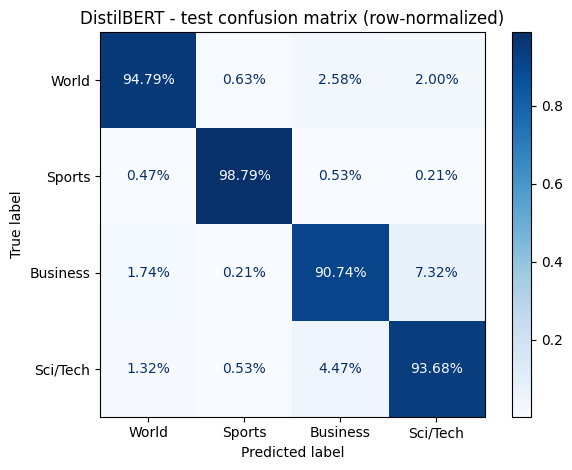

{
  "model": "distilbert-base-uncased",
  "train_size": 108000,
  "val_size": 12000,
  "test_size": 7600,
  "test_accuracy": 94.5,
  "test_macro_f1": 94.5,
  "per_class_f1": {
    "World": 95.59,
    "Sports": 98.71,
    "Business": 91.51,
    "Sci/Tech": 92.2
  },
  "training_minutes": 10.2
}


In [8]:
pred = trainer.predict(test_tok)
y_true, y_pred = pred.label_ids, pred.predictions.argmax(-1)
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
print(f"TEST accuracy: {acc*100:.2f}% | macro precision {p*100:.2f}% | macro recall {r*100:.2f}% | macro F1 {f*100:.2f}%\n")
report = classification_report(y_true, y_pred, target_names=LABELS, digits=4, output_dict=True)
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

cm = confusion_matrix(y_true, y_pred, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Blues", values_format=".2%")
plt.title("DistilBERT - test confusion matrix (row-normalized)"); plt.tight_layout()
plt.savefig("distilbert_confusion_matrix.png", dpi=150); plt.show()

results = {"model": MODEL, "train_size": len(train_ds), "val_size": len(val_ds), "test_size": len(test_ds),
           "test_accuracy": round(acc*100, 2), "test_macro_f1": round(f*100, 2),
           "per_class_f1": {l: round(report[l]["f1-score"]*100, 2) for l in LABELS},
           "training_minutes": round(train_out.metrics["train_runtime"]/60, 1)}
json.dump(results, open("distilbert_results.json", "w"), indent=2)
print(json.dumps(results, indent=2))

## 6. Most common mistakes

In [9]:
pairs = {}
for t, pr in zip(y_true, y_pred):
    if t != pr: pairs[(LABELS[t], LABELS[pr])] = pairs.get((LABELS[t], LABELS[pr]), 0) + 1
for (t, pr), n in sorted(pairs.items(), key=lambda x: -x[1])[:5]: print(f"{t:9s} predicted as {pr:9s}: {n}")
wrong = np.where(y_true != y_pred)[0][:5]
for i in wrong: print(f"\nTRUE {LABELS[y_true[i]]} | PRED {LABELS[y_pred[i]]}\n  {test_ds[int(i)]['text'][:180]}")

Business  predicted as Sci/Tech : 139
Sci/Tech  predicted as Business : 85
World     predicted as Business : 49
World     predicted as Sci/Tech : 38
Business  predicted as World    : 33

TRUE Sci/Tech | PRED Business
  IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.

TRUE Sci/Tech | PRED Business
  Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's ha

TRUE World | PRED Business
  Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market.

TRUE World | PRED Sports
  Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.

TRUE Business | PRED Sci/Tech
  Intel to delay product aimed for high-definition TVs SAN FRANCISCO -- 

## 7. Try it

In [10]:
def classify(text):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=128).to(trainer.model.device)
    with torch.no_grad(): probs = torch.softmax(trainer.model(**enc).logits, -1)[0].cpu().numpy()
    return {l: f"{p*100:.1f}%" for l, p in sorted(zip(LABELS, probs), key=lambda x: -x[1])}
for t in ["Astros beat the Yankees 5-3 to reach the World Series",
          "Apple unveils a new AI chip for faster on-device computing",
          "Oil prices climb as OPEC agrees to cut production",
          "UN Security Council meets over escalating border conflict"]:
    print(t, "->", classify(t))

Astros beat the Yankees 5-3 to reach the World Series -> {'Sports': '78.6%', 'World': '20.9%', 'Business': '0.3%', 'Sci/Tech': '0.2%'}
Apple unveils a new AI chip for faster on-device computing -> {'Sci/Tech': '98.5%', 'Business': '1.2%', 'World': '0.3%', 'Sports': '0.0%'}
Oil prices climb as OPEC agrees to cut production -> {'Business': '98.2%', 'World': '1.7%', 'Sci/Tech': '0.1%', 'Sports': '0.0%'}
UN Security Council meets over escalating border conflict -> {'World': '99.7%', 'Business': '0.2%', 'Sci/Tech': '0.1%', 'Sports': '0.0%'}


## 8. Download results
Download these three files from the Colab file panel (left sidebar, folder icon) and send them over:
`distilbert_results.json`, `distilbert_confusion_matrix.png`, `distilbert_loss_curve.png`.

Also: File > Download > Download .ipynb, so the saved notebook has all outputs.